In [1]:
# Importar bibliotecas
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import numpy as np

In [2]:
n=10

#Rotulos dos materiais
matLabels = ['Water 1', 'I8mg', 'Adipose', 'Au8mg', 'Au2mg', 'Gd8mg', 'Gd2mg', 'I18mg', 'Ca140mg', 'Ar']


#_color = ['blue', 'blue', 'red', 'orange', 'green', 'green', 'purple', 'purple', 'peru', 'gold']
_color = ['black', 'blue', 'orange', 'red', 'red', 'green', 'green', 'blue', 'purple', 'black']

#Numeros CTs para baixa energia 120 keV
ctL = np.array([35610.08990519,
                48040.26041168,
                31426.08059535,
                47222.08047873,
                38779.51531613,
                45483.04518744,
                38322.37846943,
                62589.56895146,
                59999.34919998,
                7070.62614568])

#Erros para baixa energia
ctErrorL = np.array([569.96725141,
                     676.80454723,
                     698.29003551,
                     792.78749817,
                     732.98672141,
                     654.18139301,
                     742.89415627,
                     699.11084422,
                    1277.52149135,
                     558.40629247])
 
#Numeros CTs para alta energia 120 keV
ctH = np.array([19372.73283523,
                22068.68153348,
                18002.27197692,
                22259.09057030,
                19908.69079958,
                23734.29502598,
                20873.03745840,
                25621.35139945,
                22684.23760033,
                3709.74094473])

#Erros para alta energia
ctErrorH = np.array([196.7172701,
                    227.12122315,
                    255.95321656,
                    222.74939931,
                    258.4957856 ,
                    219.99948937,
                    262.39925261,
                    217.17133660,
                    254.55964459,
                    210.67837122]) 

#Razao CT
ctRatio = ctL / ctH

In [3]:
print('Material \t ctRatio \t 1/ctRatio \t CT-60kv[Error] \t\t CT-120keV[Error]')
for i in range(n):
    print(f'{matLabels[i]}\t\t{ctRatio[i]:.6f}\t{1/ctRatio[i]:.6f}\t{ctL[i]:12.6f}[{ctErrorL[i]:.2f},{(100*ctErrorL[i]/ctL[i]):.2f}]\t{ctH[i]:12.6f}[{ctErrorH[i]:.6f},{(100*ctErrorH[i]/ctH[i]):.2f}]')

Material 	 ctRatio 	 1/ctRatio 	 CT-60kv[Error] 		 CT-120keV[Error]
Water 1		1.838155	0.544024	35610.089905[569.97,1.60]	19372.732835[196.717270,1.02]
I8mg		2.176852	0.459379	48040.260412[676.80,1.41]	22068.681533[227.121223,1.03]
Adipose		1.745673	0.572845	31426.080595[698.29,2.22]	18002.271977[255.953217,1.42]
Au8mg		2.121474	0.471370	47222.080479[792.79,1.68]	22259.090570[222.749399,1.00]
Au2mg		1.947869	0.513382	38779.515316[732.99,1.89]	19908.690800[258.495786,1.30]
Gd8mg		1.916343	0.521827	45483.045187[654.18,1.44]	23734.295026[219.999489,0.93]
Gd2mg		1.835975	0.544670	38322.378469[742.89,1.94]	20873.037458[262.399253,1.26]
I18mg		2.442868	0.409355	62589.568951[699.11,1.12]	25621.351399[217.171337,0.85]
Ca140mg		2.644980	0.378075	59999.349200[1277.52,2.13]	22684.237600[254.559645,1.12]
Ar		1.905962	0.524669	 7070.626146[558.41,7.90]	 3709.740945[210.678371,5.68]


<ErrorbarContainer object of 3 artists>

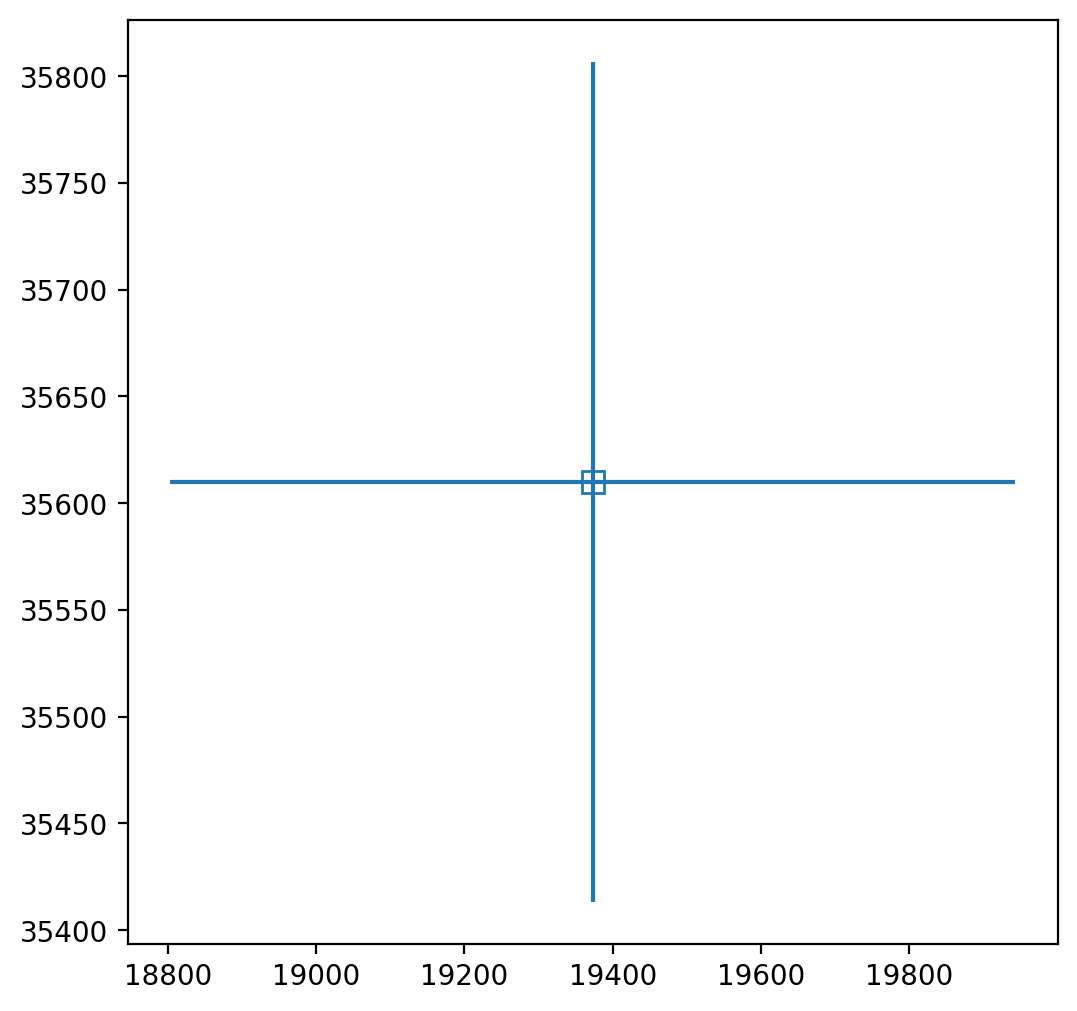

In [4]:
plt.figure(figsize=(6, 6), dpi=200)

#plt.plot(ctH[0], ctL[0], label=matLabels[0], marker='x')
plt.errorbar(ctH[0], ctL[0], ctErrorH[0], ctErrorL[0], label=matLabels[0], 
              marker='s', markersize=8, fillstyle='none')

#plt.xlim((1000, 65536))
#plt.ylim((1000, 65536))

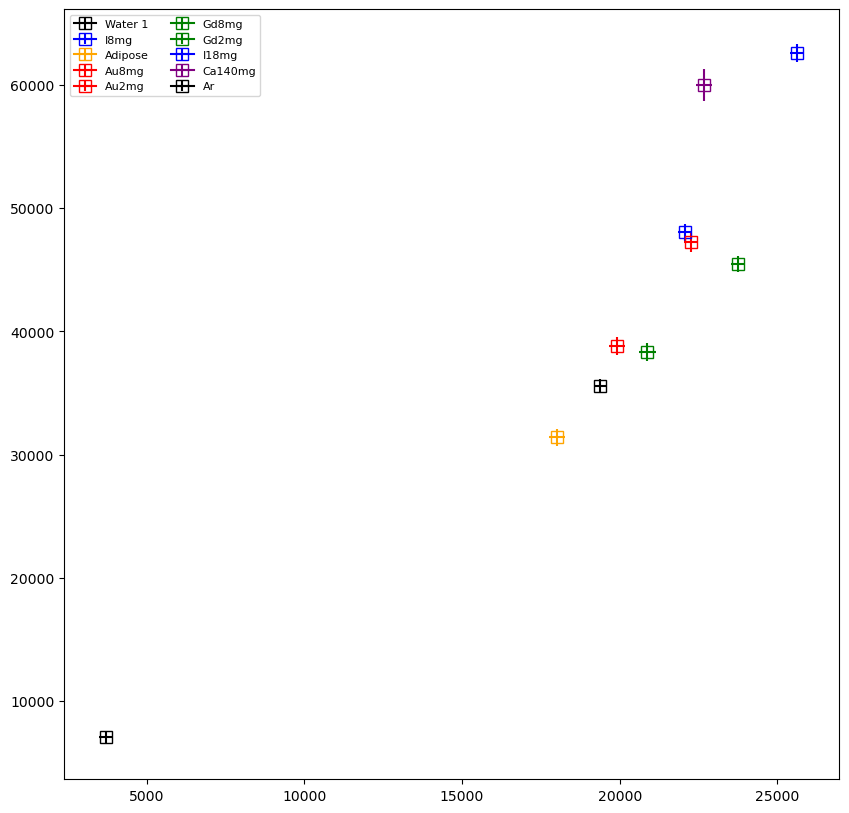

In [5]:
plt.figure(figsize=(10, 10), dpi=100)

for i in range(n):
    plt.errorbar(ctH[i], ctL[i], yerr=ctErrorL[i], xerr=ctErrorH[i],  label=matLabels[i], 
                  marker='s', markersize=8, fillstyle='none', color = _color[i])
    
plt.legend(loc="upper left", ncol=2, fontsize="8")    

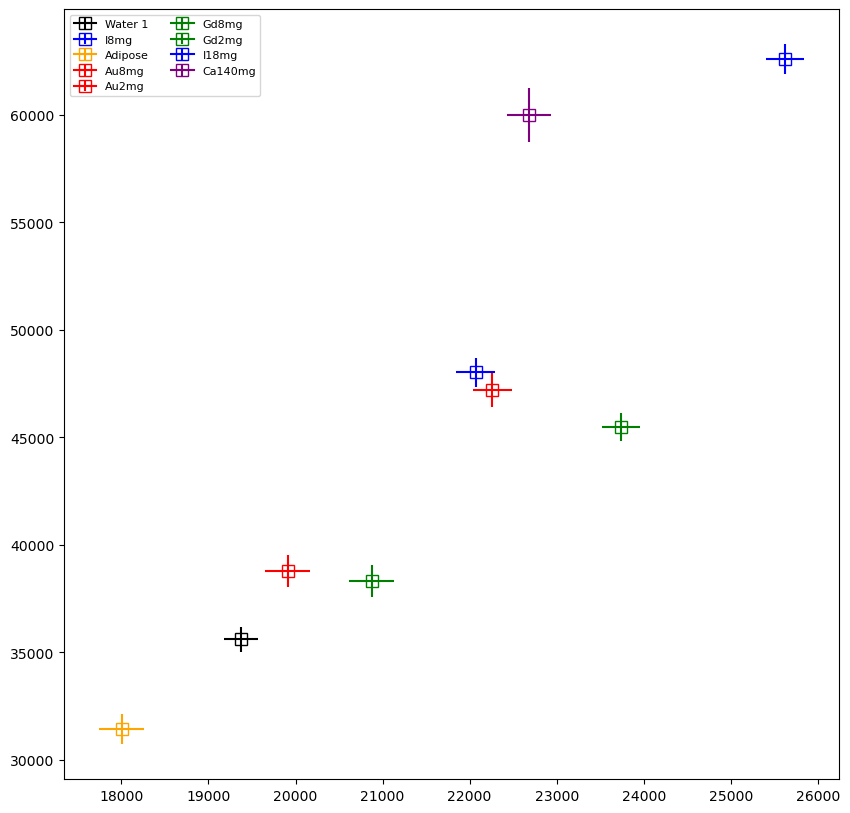

In [6]:
plt.figure(figsize=(10, 10), dpi=100)

for i in range(n-1):
    plt.errorbar(ctH[i], ctL[i], yerr = ctErrorL[i], xerr = ctErrorH[i], label=matLabels[i], 
                  marker='s', markersize=8, fillstyle='none', color = _color[i])
    
plt.legend(loc="upper left", ncol=2, fontsize="8")
#plt.xlim((1.3E4, 2.5E4))
#plt.ylim((2.0E4, 5.5E4))

In [7]:
def createRectTwoPoints(P1, P2):
    m = (P1[1]-P2[1])/(P1[0]-P2[0])
    n = (P1[1]-m*P1[0])

    return (m, n)

In [8]:
#m, n = createRectTwoPoints((0,0), (1,1))
#m, n = createRectTwoPoints((0,2), (1,2.5))

#print(m,n)

In [9]:
#Reta Ar e Agua
(mAguaAr, nAguaAr) = createRectTwoPoints((ctH[0],ctL[0]), (ctH[9],ctL[9]))
#Reta do Iodo
(mI, nI) = createRectTwoPoints((ctH[0],ctL[0]), (ctH[7],ctL[7])) 
(mGd, nGd) = createRectTwoPoints((ctH[0],ctL[0]), (ctH[5],ctL[5])) 
(mAu, nAu) = createRectTwoPoints((ctH[0],ctL[0]), (ctH[3],ctL[3])) 



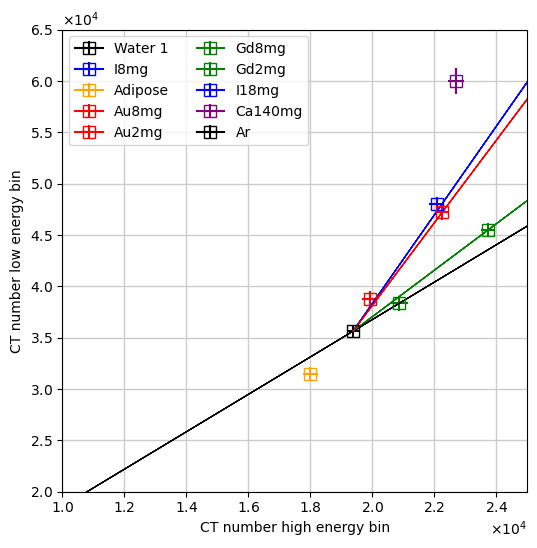

In [13]:
xdata = np.linspace(ctH.min(), ctH.max()+1000, 1000)
xdataLin = xdata[xdata >= ctH[0]]
yAguaAr = mAguaAr*xdata + nAguaAr
yIodo = mI*xdataLin + nI
yGd = mGd*xdataLin + nGd
yAu = mAu*xdataLin + nAu


plt.figure(figsize=(6, 6))

for i in range(n):
    plt.errorbar(ctH[i], ctL[i], yerr = ctErrorL[i], xerr = ctErrorH[i], label=matLabels[i], 
                  marker='s', markersize=8, fillstyle='none', color = _color[i])
    plt.plot(xdata, yAguaAr, color='black', label=None, linewidth=0.7)
    plt.plot(xdataLin, yIodo, color='blue', label=None, linewidth=0.7)
    plt.plot(xdataLin, yGd, color='green', label=None, linewidth=0.7)
    plt.plot(xdataLin, yAu, color='red', label=None, linewidth=0.7)

plt.xlim((1.0E4, 2.5E4))
plt.ylim((2.0E4, 6.5E4))
plt.legend(loc="upper left", ncol=2, fontsize="10")
plt.ticklabel_format(axis='both', style='sci', scilimits=(1,2), useMathText=True)
plt.xlabel('CT number high energy bin')
plt.ylabel('CT number low energy bin')
plt.grid(visible=True, which='major', axis='both', color='#cccccc', linestyle='-', linewidth=1) 

In [16]:
def converToHU(_ct, _pW, _pA):
    _n = len(_ct)
    _uWater = _ct[_pW]
    _uAir = _ct[_pA]

    _hu = np.zeros(_n)
    for i in range(_n):
        _hu[i] = 1000*(_ct[i] - _uWater)/(_uWater - _uAir)

    return _hu    


In [20]:
huL = converToHU(ctL, 0, 9)
huH = converToHU(ctH, 0, 9)
print(huL)
print(huH)

[    0.           435.54323975  -146.60434215   406.87486883
   111.05413324   345.94046214    95.0364235    945.33938246
   854.5801526  -1000.        ]
[    0.           172.12220482   -87.49674825   184.27882459
    34.21810904   278.46290295    95.7865926    398.94156927
   211.42223582 -1000.        ]


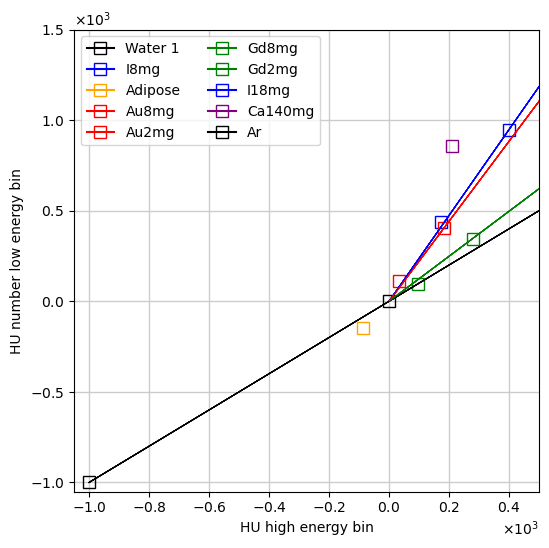

In [27]:
#Reta Ar e Agua
(mAguaAr, nAguaAr) = createRectTwoPoints((huH[0],huL[0]), (huH[9],huL[9]))
#Reta do Iodo
(mI, nI) = createRectTwoPoints((huH[0],huL[0]), (huH[7],huL[7])) 
(mGd, nGd) = createRectTwoPoints((huH[0],huL[0]), (huH[5],huL[5])) 
(mAu, nAu) = createRectTwoPoints((huH[0],huL[0]), (huH[3],huL[3])) 

xdata = np.linspace(huH.min(), huH.max()+1000, 1000)
xdataLin = xdata[xdata >= 0]
yAguaAr = mAguaAr*xdata + nAguaAr
yIodo = mI*xdataLin + nI
yGd = mGd*xdataLin + nGd
yAu = mAu*xdataLin + nAu


plt.figure(figsize=(6, 6))

for i in range(n):
    plt.plot(huH[i], huL[i], label=matLabels[i], 
                  marker='s', markersize=8, fillstyle='none', color = _color[i])
    plt.plot(xdata, yAguaAr, color='black', label=None, linewidth=0.7)
    plt.plot(xdataLin, yIodo, color='blue', label=None, linewidth=0.7)
    plt.plot(xdataLin, yGd, color='green', label=None, linewidth=0.7)
    plt.plot(xdataLin, yAu, color='red', label=None, linewidth=0.7)

plt.xlim((-1.05E3, 0.5E3))
plt.ylim((-1.05E3, 1.5E3))
plt.legend(loc="upper left", ncol=2, fontsize="10")
plt.ticklabel_format(axis='both', style='sci', scilimits=(1,2), useMathText=True)
plt.xlabel('HU high energy bin')
plt.ylabel('HU number low energy bin')
plt.grid(visible=True, which='major', axis='both', color='#cccccc', linestyle='-', linewidth=1) 

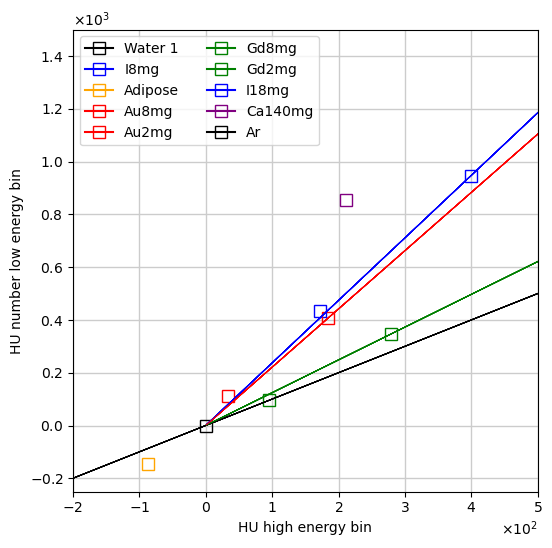

In [28]:
plt.figure(figsize=(6, 6))

for i in range(n):
    plt.plot(huH[i], huL[i], label=matLabels[i], 
                  marker='s', markersize=8, fillstyle='none', color = _color[i])
    plt.plot(xdata, yAguaAr, color='black', label=None, linewidth=0.7)
    plt.plot(xdataLin, yIodo, color='blue', label=None, linewidth=0.7)
    plt.plot(xdataLin, yGd, color='green', label=None, linewidth=0.7)
    plt.plot(xdataLin, yAu, color='red', label=None, linewidth=0.7)

plt.xlim((-0.2E3, 0.5E3))
plt.ylim((-0.25E3, 1.5E3))
plt.legend(loc="upper left", ncol=2, fontsize="10")
plt.ticklabel_format(axis='both', style='sci', scilimits=(1,2), useMathText=True)
plt.xlabel('HU high energy bin')
plt.ylabel('HU number low energy bin')
plt.grid(visible=True, which='major', axis='both', color='#cccccc', linestyle='-', linewidth=1) 